# Feature Extraction

This notebook loads the cleaned UrbanSound8K metadate from the previous notebook, extracts audio features, and saves them in ready-to-use files for the next notebook.

## Imports and Paths

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from src.feature_extraction import load_audio_fixed_length, extract_features

ROOT = Path.cwd().parent.resolve()

PROCESSED_DIR = ROOT / "data/processed"
FEATURE_DIR = ROOT / "data/features"

FEATURE_DIR.mkdir(parents=True, exist_ok=True)

METADATA_DIR = PROCESSED_DIR / "urbansound8k_metadata_clean.csv"
CV_PLAN_DIR = PROCESSED_DIR / "cv_plan_10fold.json"

print("Metadata path:", METADATA_DIR)
print("Feature output dir:", FEATURE_DIR)

Metadata path: D:\Projects\Audio\Audio Pattern Recognition\data\processed\urbansound8k_metadata_clean.csv
Feature output dir: D:\Projects\Audio\Audio Pattern Recognition\data\features


d:\Programs\anaconda3\envs\kaggle\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Loading Cleaned Metadata

In [2]:
metadata = pd.read_csv(METADATA_DIR)

print(metadata.shape)
display(metadata.head())

print("Classes:", sorted(metadata["class"].unique()))
print("Folds:", sorted(int(fold) for fold in metadata["fold"].unique()))

(8732, 9)


,slice_file_name,fsID,start,end,salience,fold,classID,class,audio_path
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark,D:\Projects\Audio\Audio Pattern Recognition\da...
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing,D:\Projects\Audio\Audio Pattern Recognition\da...
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing,D:\Projects\Audio\Audio Pattern Recognition\da...
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing,D:\Projects\Audio\Audio Pattern Recognition\da...
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing,D:\Projects\Audio\Audio Pattern Recognition\da...


Classes: ['air_conditioner', 'car_horn', 'children_playing', 'dog_bark', 'drilling', 'engine_idling', 'gun_shot', 'jackhammer', 'siren', 'street_music']
Folds: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


## Feature Extraction Parameters

In [3]:
CONFIG = {
    "sample_rate": 22050,
    "duration": 4.0,
    "n_fft": 2048,
    "hop_length": 512,
    "n_mels": 128,
    "n_mfcc": 40,
}

CONFIG["target_length"] = int(CONFIG["sample_rate"] * CONFIG["duration"])
CONFIG

{'sample_rate': 22050,
 'duration': 4.0,
 'n_fft': 2048,
 'hop_length': 512,
 'n_mels': 128,
 'n_mfcc': 40,
 'target_length': 88200}

## Visual Sanity Check on One Audio Clip

In [4]:
example_row = metadata.iloc[0]
example_path = example_row["audio_path"]

y = load_audio_fixed_length(
    example_path,
    sample_rate=CONFIG["sample_rate"],
    target_length=CONFIG["target_length"],
)

example_features, features_names, example_logmel = extract_features(
    example_path, CONFIG
)

example_mfcc = librosa.feature.mfcc(
    y=y,
    sr=CONFIG["sample_rate"],
    n_mfcc=CONFIG["n_mfcc"],
    n_fft=CONFIG["n_fft"],
    hop_length=CONFIG["hop_length"],
)

print("Example file:", example_row["slice_file_name"])
print("Class:", example_row["class"])
print("Waveform shape", y.shape)
print("Tabular feature vector shape:", example_features.shape)
print("Log-Mel shape:", example_logmel.shape)

Example file: 100032-3-0-0.wav
Class: dog_bark
Waveform shape (88200,)
Tabular feature vector shape: (176,)
Log-Mel shape: (128, 173)


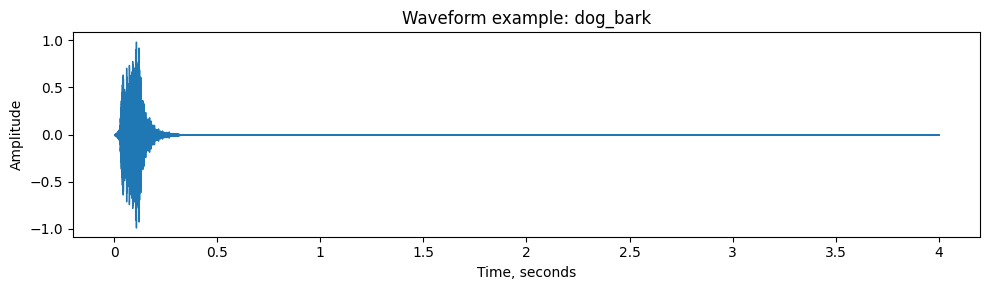

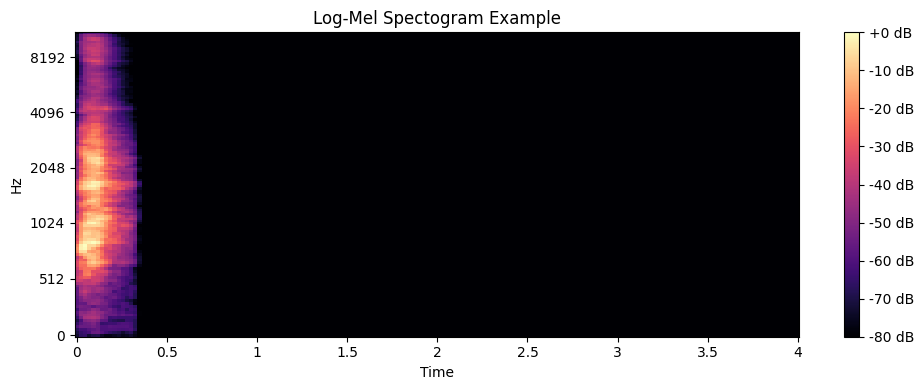

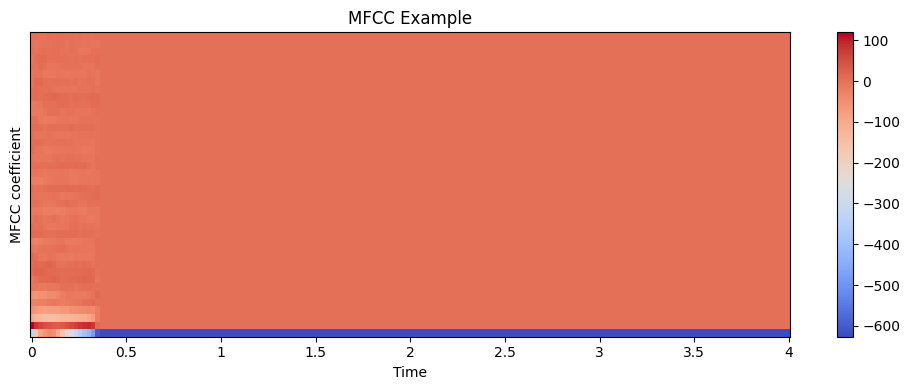

In [ ]:
from librosa import example

plt.figure(figsize=(10, 3))
librosa.display.waveshow(y, sr=CONFIG["sample_rate"])
plt.title(f"Waveform example: {example_row['class']}")
plt.xlabel("Time, seconds")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
librosa.display.specshow(
    example_logmel,
    sr=CONFIG["sample_rate"],
    hop_length=CONFIG["hop_length"],
    x_axis="time",
    y_axis="mel",
)
plt.colorbar(format="%+2.0f dB")
plt.title("Log-Mel Spectrogram Example")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
librosa.display.specshow(
    example_mfcc,
    sr=CONFIG["sample_rate"],
    hop_length=CONFIG["hop_length"],
    x_axis="time",
)
plt.colorbar()
plt.title("MFCC Example")
plt.ylabel("MFCC coefficient")
plt.tight_layout()
plt.show()

## Extracting Features for All Clips

In [ ]:
X_tabular = []
X_logmel = []
labels = []
class_ids = []
folds = []
filenames = []

feature_names = None

for _, row in tqdm(
    metadata.iterrows(), total=len(metadata), desc="Extracting features"
):
    features, names, logmel = extract_features(row["audio_path"], CONFIG)

    if feature_names is None:
        feature_names = names

    X_tabular.append(features)
    X_logmel.append(logmel)
    labels.append(row["class"])
    class_ids.append(row["classID"])
    folds.append(row["fold"])
    filenames.append(row["slice_file_name"])

X_tabular = np.asarray(X_tabular, dtype=np.float32)
X_logmel = np.asarray(X_logmel, dtype=np.float32)
labels = np.asarray(labels)
class_ids = np.asarray(class_ids, dtype=np.int64)
folds = np.asarray(folds, dtype=np.int64)
filenames = np.asarray(filenames)

print("Tabular features:", X_tabular.shape)
print("Log-Mel spectrograms:", X_logmel.shape)
print("Labels:", labels.shape)
print("Feature names:", len(feature_names))

Extracting features: 100%|██████████| 8732/8732 [08:07<00:00, 17.90it/s]


Tabular features: (8732, 176)
Log-Mel spectograms: (8732, 128, 173)
Labels: (8732,)
Feature names: 176


## Checking for Invalid Values

In [7]:
print("NaN in tabular features:", np.isnan(X_tabular).sum())
print("Inf in tabular features:", np.isinf(X_tabular).sum())

print("NaN in log-Mel:", np.isnan(X_logmel).sum())
print("Inf in log-Mel:", np.isinf(X_logmel).sum())

NaN in tabular features: 0
Inf in tabular features: 0
NaN in log-Mel: 0
Inf in log-Mel: 0


## Saving Features for the Next Notebook

In [8]:
tabular_path = FEATURE_DIR / "tabular_audio_features.npz"

np.savez_compressed(
    tabular_path,
    X=X_tabular,
    y=class_ids,
    labels=labels,
    folds=folds,
    filenames=filenames,
    feature_names=np.asarray(feature_names),
)

print("Saved:", tabular_path)

Saved: D:\Projects\Audio\Audio Pattern Recognition\data\features\tabular_audio_features.npz


In [ ]:
logmel_path = FEATURE_DIR / "logmel_spectrogram.npz"

np.savez_compressed(
    logmel_path,
    X=X_logmel,
    y=class_ids,
    labels=labels,
    folds=folds,
    filenames=filenames,
)

print("Saved:", logmel_path)

Saved: D:\Projects\Audio\Audio Pattern Recognition\data\features\logmel_spectogram.npz


In [10]:
feature_config_path = FEATURE_DIR / "feature_config.json"

with open(feature_config_path, "w") as f:
    json.dump(CONFIG, f, indent=4)

print("Saved:", feature_config_path)

Saved: D:\Projects\Audio\Audio Pattern Recognition\data\features\feature_config.json


## Final Verification

In [11]:
tabular_data = np.load(tabular_path, allow_pickle=True)
logmel_data = np.load(logmel_path, allow_pickle=True)

print("Tabular keys:", tabular_data.files)
print("Log-Mel keys:", logmel_data.files)

print("Reloaded tabular X:", tabular_data["X"].shape)
print("Reloaded Log-Mel X:", logmel_data["X"].shape)
print("Reloaded y:", tabular_data["y"].shape)
print("Reloaded folds:", tabular_data["folds"].shape)

Tabular keys: ['X', 'y', 'labels', 'folds', 'filenames', 'feature_names']
Log-Mel keys: ['X', 'y', 'labels', 'folds', 'filenames']
Reloaded tabular X: (8732, 176)
Reloaded Log-Mel X: (8732, 128, 173)
Reloaded y: (8732,)
Reloaded folds: (8732,)
